# 04. 피처 엔지니어링 & 하이퍼파라미터 튜닝

03단계에서 베이스라인을 확보했다. 이제 **점수를 올릴 차례**다.
방법은 크게 둘이고, **순서가 중요하다.**

| 순서 | 방법 | 하는 일 |
|---|---|---|
| 1️⃣ | **피처 엔지니어링** — 데이터에 없던 정보를 만든다 | 재료를 늘린다 |
| 2️⃣ | **하이퍼파라미터 튜닝** — 모델 설정을 다듬는다 | 재료를 더 잘 쓴다 |

**순서는 피처가 먼저다.** 튜닝된 파라미터는 피처셋에 맞춰 최적화된 값이라,
나중에 피처를 바꾸면 튜닝을 다시 해야 하기 때문이다. 반대 순서로 하면 일이 두 번 된다.

> **다만 "피처가 항상 더 큰 이득을 준다"고 단정하지는 말자.**
> 흔히 "피처 엔지니어링이 튜닝보다 훨씬 중요하다"고들 하는데, 이번 대회에서는
> **그렇지 않았다.** 이 노트북 마지막의 요약 표에서 직접 확인하게 될 것이다.
> 왜 그런지는 마지막 섹션에서 다룬다.

### 이 노트북의 실험 설계
1. 파생변수를 **그룹별로** 만들어 하나씩 붙여가며 CV 비교
2. 도움이 되는 그룹만 **선별** (많이 넣는다고 좋아지지 않는다)
3. 선별된 피처셋에 **Optuna 튜닝** 적용

## 0. 준비

In [1]:
import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)

SEED = 42
np.random.seed(SEED)

from preprocess import (load_data, to_category, align_categories, build_features,
                        NUM_COLS, CAT_COLS, TARGET)
from cv import get_folds, run_cv, ExperimentLog

train, test, sub = load_data('../data/')
y = train[TARGET].values
folds = get_folds(train, y, n_splits=5, seed=SEED)

# 탐색용 고속 설정 — 실험을 여러 번 돌려야 하므로 속도를 우선한다.
# 절대 점수는 조금 낮지만 '어느 피처가 나은가'라는 순위 판단에는 충분하다.
FAST = dict(objective='binary', metric='auc', learning_rate=0.1,
            num_leaves=31, min_child_samples=50,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
            n_estimators=1000, verbose=-1, n_jobs=-1, random_state=SEED)
FAST_FIT = dict(eval_metric='auc',
                callbacks=[lgb.early_stopping(60, verbose=False)])

def quick_cv(X_variant, name):
    r = run_cv(lambda: lgb.LGBMClassifier(**FAST), X_variant, y,
               folds=folds, name=name, fit_params=FAST_FIT, verbose=False)
    print(f'{name:30s} AUC = {r["cv_auc"]:.6f}  '
          f'(폴드 표준편차 {r["fold_std"]:.6f}, 열 {X_variant.shape[1]}개)')
    return r

print('준비 완료')

준비 완료


## 1. 파생변수 설계 — 왜 이 변수들인가

아무 변수나 곱하고 나눠서 만드는 게 아니다. **01단계 EDA에서 본 것**과
**도메인 상식**에 근거해야 한다.

### 근거 1 — 스크린타임 변수끼리 상관이 0.80으로 매우 높다
`daily_screen_time`과 `weekend_screen_time`이 거의 같은 정보를 담고 있다.
→ 두 값의 **비율**을 만들면 "평일 대비 주말에 얼마나 더 쓰는가"라는
   **원본에 없던 패턴 정보**가 생긴다.

### 근거 2 — 같은 5시간도 '무엇에 썼는가'가 다르다
SNS 4시간 + 게임 1시간인 사람과, 공부 4시간 + SNS 1시간인 사람은
총 스크린타임이 같아도 성격이 완전히 다르다.
→ **구성 비율**(`social / daily`)이 절대 시간과 다른 정보를 담는다.

### 근거 3 — 하루는 24시간으로 정해져 있다
잠자는 시간을 빼면 쓸 수 있는 시간이 정해진다.
→ **깨어있는 시간 중 화면 비중**은 절대 시간보다 '몰입도'를 잘 나타낼 수 있다.

In [2]:
# src/preprocess.py의 build_features()가 아래 12개를 한 번에 만든다.
# 실험을 위해 5개 그룹으로 나눠 관리한다.
fe = to_category(build_features(train[NUM_COLS + CAT_COLS]))

GROUPS = {
    '주말패턴': ['weekend_ratio', 'weekend_diff'],
    '구성비율': ['social_ratio', 'gaming_ratio', 'study_ratio'],
    '여가지표': ['leisure_hours', 'leisure_vs_study'],
    '시간예산': ['awake_hours', 'screen_per_awake', 'sleep_screen_sum'],
    '사용강도': ['mins_per_open', 'opens_per_notif'],
}

desc = pd.DataFrame([
    ('주말패턴', 'weekend_ratio', 'weekend / daily', '주말에 몇 배 더 쓰는가'),
    ('주말패턴', 'weekend_diff', 'weekend - daily', '주말 증가량(시간)'),
    ('구성비율', 'social_ratio', 'social / daily', '스크린타임 중 SNS 비중'),
    ('구성비율', 'gaming_ratio', 'gaming / daily', '스크린타임 중 게임 비중'),
    ('구성비율', 'study_ratio', 'work_study / daily', '스크린타임 중 공부 비중'),
    ('여가지표', 'leisure_hours', 'social + gaming', '순수 여가성 사용 시간'),
    ('여가지표', 'leisure_vs_study', '(social+gaming) / work_study', '여가 대 생산성 비'),
    ('시간예산', 'awake_hours', '24 - sleep', '깨어있는 시간'),
    ('시간예산', 'screen_per_awake', 'daily / (24-sleep)', '깨어있는 시간 중 화면 비중'),
    ('시간예산', 'sleep_screen_sum', 'sleep + daily', '잠+화면이 하루에서 차지하는 양'),
    ('사용강도', 'mins_per_open', 'daily*60 / app_opens', '한 번 열 때 보는 시간(분)'),
    ('사용강도', 'opens_per_notif', 'app_opens / notifications', '알림 대비 자발적 실행'),
], columns=['그룹', '변수명', '계산식', '의미'])
desc

,그룹,변수명,계산식,의미
0,주말패턴,weekend_ratio,weekend / daily,주말에 몇 배 더 쓰는가
1,주말패턴,weekend_diff,weekend - daily,주말 증가량(시간)
2,구성비율,social_ratio,social / daily,스크린타임 중 SNS 비중
3,구성비율,gaming_ratio,gaming / daily,스크린타임 중 게임 비중
4,구성비율,study_ratio,work_study / daily,스크린타임 중 공부 비중
5,여가지표,leisure_hours,social + gaming,순수 여가성 사용 시간
6,여가지표,leisure_vs_study,(social+gaming) / work_study,여가 대 생산성 비
7,시간예산,awake_hours,24 - sleep,깨어있는 시간
8,시간예산,screen_per_awake,daily / (24-sleep),깨어있는 시간 중 화면 비중
9,시간예산,sleep_screen_sum,sleep + daily,잠+화면이 하루에서 차지하는 양


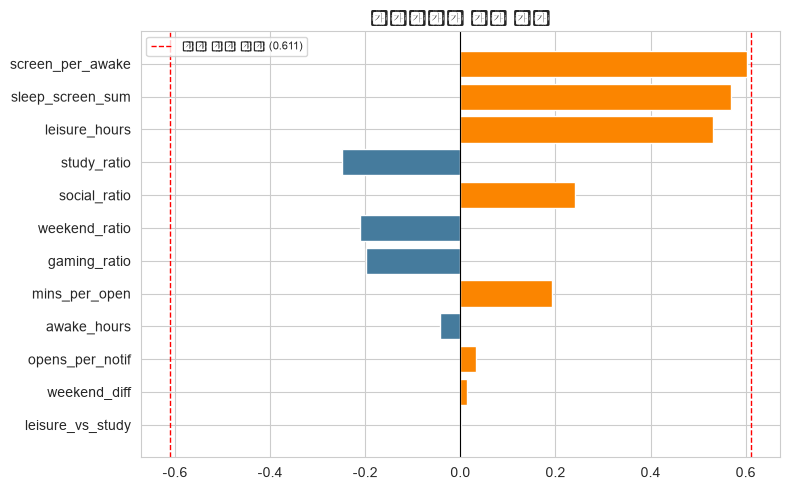

              변수   타깃 상관    절댓값
screen_per_awake  0.6023 0.6023
sleep_screen_sum  0.5682 0.5682
   leisure_hours  0.5309 0.5309
     study_ratio -0.2492 0.2492
    social_ratio  0.2411 0.2411
   weekend_ratio -0.2105 0.2105
    gaming_ratio -0.1994 0.1994
   mins_per_open  0.1934 0.1934
     awake_hours -0.0425 0.0425
 opens_per_notif  0.0319 0.0319
    weekend_diff  0.0136 0.0136
leisure_vs_study  0.0014 0.0014


In [3]:
# 만든 파생변수가 타깃과 얼마나 관련 있는지 먼저 확인한다.
# (원본 변수의 최고 상관은 daily_screen_time의 0.611이었다)
new_cols = [c for g in GROUPS.values() for c in g]
fe_corr = pd.DataFrame({
    '변수': new_cols,
    '타깃 상관': [fe[c].corr(pd.Series(y)) for c in new_cols],
})
fe_corr['절댓값'] = fe_corr['타깃 상관'].abs()
fe_corr = fe_corr.sort_values('절댓값', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#fb8500' if v > 0 else '#457b9d' for v in fe_corr['타깃 상관']]
ax.barh(fe_corr['변수'][::-1], fe_corr['타깃 상관'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.611, color='red', ls='--', lw=1, label='원본 최고 상관 (0.611)')
ax.axvline(-0.611, color='red', ls='--', lw=1)
ax.set_title('파생변수의 타깃 상관')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(fe_corr.round(4).to_string(index=False))

> **주의**: 상관이 높다고 반드시 좋은 피처는 아니다.
> 원본 변수와 **거의 같은 정보**를 담고 있으면 새로 추가할 게 없다.
> 결국 판단은 **CV 점수**로 해야 한다. 상관은 참고용일 뿐이다.

## 2. 그룹별 효과 측정

한 번에 12개를 다 넣으면 **어느 것이 효과가 있었는지 알 수 없다.**
그룹을 하나씩만 추가해서 각각의 순수 효과를 측정한다.

이런 방식을 **애블레이션(ablation) 실험**이라고 한다.
하나씩 넣거나 빼면서 그 요소의 기여도를 분리해내는 방법이다.

In [4]:
BASE = NUM_COLS + CAT_COLS
log = ExperimentLog()

# ⏱ 그룹당 약 1.5분, 전체 6회 실행에 약 8~10분
r0 = quick_cv(fe[BASE], '베이스라인 (원본 12개)')
log.add('베이스라인 (원본 12개)', r0['cv_auc'], '03단계와 동일 조건')

베이스라인 (원본 12개)                 AUC = 0.962750  (폴드 표준편차 0.000700, 열 12개)


In [5]:
group_results = {}
for gname, gcols in GROUPS.items():
    r = quick_cv(fe[BASE + gcols], f'+ {gname}')
    group_results[gname] = r
    log.add(f'+ {gname}', r['cv_auc'], f'추가 열 {len(gcols)}개: {", ".join(gcols)}')

+ 주말패턴                         AUC = 0.962859  (폴드 표준편차 0.000685, 열 14개)


+ 구성비율                         AUC = 0.963426  (폴드 표준편차 0.000475, 열 15개)


+ 여가지표                         AUC = 0.963091  (폴드 표준편차 0.000591, 열 14개)


+ 시간예산                         AUC = 0.962734  (폴드 표준편차 0.001047, 열 15개)


+ 사용강도                         AUC = 0.962869  (폴드 표준편차 0.000565, 열 14개)


In [6]:
# 파생변수 12개를 전부 넣으면 어떻게 되는지도 확인한다.
# "많이 넣으면 좋겠지"라는 직관이 맞는지 검증하는 셀이다.
r_all = quick_cv(fe, '+ 전체 파생변수(12개)')
log.add('+ 전체 파생변수(12개)', r_all['cv_auc'], '12개 모두 추가')

+ 전체 파생변수(12개)                 AUC = 0.963167  (폴드 표준편차 0.000578, 열 24개)


            실험   CV AUC  베이스라인 대비                                                       비고
        + 구성비율 0.963426  0.000676         추가 열 3개: social_ratio, gaming_ratio, study_ratio
+ 전체 파생변수(12개) 0.963167  0.000417                                                12개 모두 추가
        + 여가지표 0.963091  0.000341                 추가 열 2개: leisure_hours, leisure_vs_study
        + 사용강도 0.962869  0.000119                  추가 열 2개: mins_per_open, opens_per_notif
        + 주말패턴 0.962859  0.000109                     추가 열 2개: weekend_ratio, weekend_diff
베이스라인 (원본 12개) 0.962750  0.000000                                              03단계와 동일 조건
        + 시간예산 0.962734 -0.000016 추가 열 3개: awake_hours, screen_per_awake, sleep_screen_sum


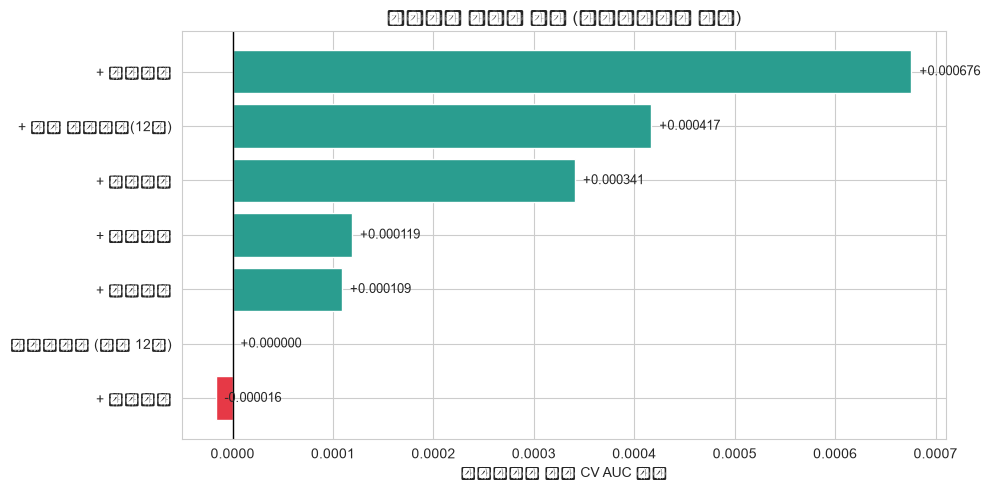

In [7]:
res = log.to_frame()
print(res.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
d = res.sort_values('CV AUC')
colors = ['#adb5bd' if '베이스라인' in s else
          ('#2a9d8f' if v > 0 else '#e63946')
          for s, v in zip(d['실험'], d['베이스라인 대비'])]
ax.barh(d['실험'], d['베이스라인 대비'], color=colors)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('베이스라인 대비 CV AUC 변화')
ax.set_title('파생변수 그룹별 효과 (오른쪽일수록 개선)')
for i, v in enumerate(d['베이스라인 대비']):
    ax.text(v, i, f'  {v:+.6f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 해석 — "많이 넣으면 좋다"는 틀렸다

**전체 12개를 다 넣은 것보다 좋은 그룹 하나만 넣은 것이 더 좋다.**
직관에 반하지만 이유가 있다.

LightGBM은 트리를 만들 때마다 **모든 후보 변수를 검토**해서 최적 분기를 찾는다.
기여도가 낮은 변수가 섞여 있으면:
1. 그 변수로 분기하는 트리가 **우연히** 만들어질 수 있고 (노이즈 학습)
2. `feature_fraction=0.8` 때문에 **정작 좋은 변수가 후보에서 빠지는** 일이 잦아진다

즉 쓸모없는 피처는 **중립이 아니라 마이너스**다.

> **캐글 실무 감각**: 피처를 100개 만들었다면, 그중 **점수를 올리는 10개만
> 남기는 작업**이 진짜 피처 엔지니어링이다. 만드는 것보다 **버리는 것**이 어렵다.

## 3. 최종 피처셋 선별

효과가 확인된 요소를 **조합**해서 최적 지점을 찾는다.
03단계에서 좋았던 `n_missing`(행별 결측 개수)도 함께 넣어 재검증한다.

In [8]:
# 03단계에서 효과가 확인된 n_missing
nmiss = train[NUM_COLS + CAT_COLS].isnull().sum(axis=1).astype(np.int8)

def with_nm(cols):
    X = fe[cols].copy()
    X['n_missing'] = nmiss
    return X

RATIO = GROUPS['구성비율']
LEIS  = GROUPS['여가지표']
WKND  = GROUPS['주말패턴']
INTS  = GROUPS['사용강도']

combo = ExperimentLog()
r = quick_cv(fe[BASE], 'K0. 베이스라인');            combo.add('K0. 베이스라인', r['cv_auc'], '원본 12개')
r = quick_cv(with_nm(BASE + RATIO), 'K1. +n_missing +구성비율');  combo.add('K1. +n_missing +구성비율', r['cv_auc'], '16개')
r = quick_cv(with_nm(BASE + RATIO + LEIS), 'K2. K1 +여가지표');   combo.add('K2. K1 +여가지표', r['cv_auc'], '18개')
r = quick_cv(with_nm(BASE + RATIO + LEIS + WKND), 'K3. K2 +주말패턴'); combo.add('K3. K2 +주말패턴', r['cv_auc'], '20개')
r = quick_cv(with_nm(BASE + RATIO + LEIS + WKND + INTS), 'K4. K3 +사용강도'); combo.add('K4. K3 +사용강도', r['cv_auc'], '22개')

K0. 베이스라인                      AUC = 0.962750  (폴드 표준편차 0.000700, 열 12개)


K1. +n_missing +구성비율           AUC = 0.963546  (폴드 표준편차 0.000606, 열 16개)


K2. K1 +여가지표                   AUC = 0.963537  (폴드 표준편차 0.000520, 열 18개)


K3. K2 +주말패턴                   AUC = 0.963031  (폴드 표준편차 0.000890, 열 20개)


K4. K3 +사용강도                   AUC = 0.963024  (폴드 표준편차 0.000611, 열 22개)


                  실험   CV AUC  베이스라인 대비     비고
K1. +n_missing +구성비율 0.963546  0.000796    16개
        K2. K1 +여가지표 0.963537  0.000787    18개
        K3. K2 +주말패턴 0.963031  0.000281    20개
        K4. K3 +사용강도 0.963024  0.000274    22개
           K0. 베이스라인 0.962750  0.000000 원본 12개


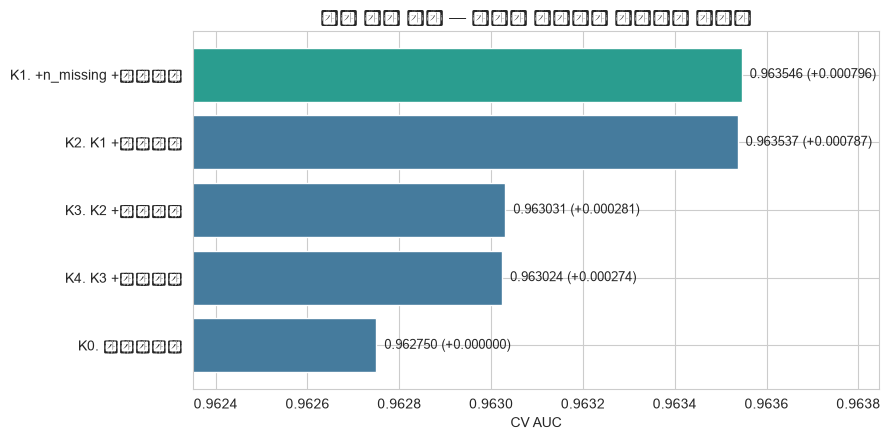


최고 조합: K1. +n_missing +구성비율  (CV AUC 0.963546)


In [9]:
cdf = combo.to_frame()
print(cdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
d = cdf.sort_values('CV AUC')
ax.barh(d['실험'], d['CV AUC'],
        color=['#2a9d8f' if v == d['CV AUC'].max() else '#457b9d' for v in d['CV AUC']])
ax.set_xlim(d['CV AUC'].min() - 0.0004, d['CV AUC'].max() + 0.0003)
ax.set_xlabel('CV AUC')
ax.set_title('피처 조합 실험 — 피처를 늘릴수록 좋아지지 않는다')
for i, (v, dl) in enumerate(zip(d['CV AUC'], d['베이스라인 대비'])):
    ax.text(v, i, f'  {v:.6f} ({dl:+.6f})', va='center', fontsize=9)
plt.tight_layout(); plt.show()

best_name = cdf.iloc[0]['실험']
print(f'\n최고 조합: {best_name}  (CV AUC {cdf.iloc[0]["CV AUC"]:.6f})')

In [10]:
# 확정된 최종 피처셋을 src/preprocess.py의 build_final()로 재현한다.
# (05단계 앙상블에서도 똑같은 피처셋을 써야 하므로 함수로 고정해둔다)
from preprocess import build_final, SELECTED_EXTRA

X, X_test, use_cols = build_final(train, test)

print(f'최종 피처 {len(use_cols)}개')
print(f'  원본 12개 + 추가 {len(SELECTED_EXTRA)}개: {SELECTED_EXTRA}')
print(f'  X {X.shape} / X_test {X_test.shape}')
assert list(X.columns) == list(X_test.columns)
print('✅ train/test 열 구성 일치')

최종 피처 16개
  원본 12개 + 추가 4개: ['n_missing', 'social_ratio', 'gaming_ratio', 'study_ratio']
  X (691369, 16) / X_test (296302, 16)
✅ train/test 열 구성 일치


## 4. 하이퍼파라미터 튜닝 (Optuna)

피처를 확정했으니 이제 모델 설정을 다듬는다.

### Optuna란
하이퍼파라미터를 자동으로 탐색해주는 라이브러리다.
**베이지안 최적화**를 쓰는데, 원리는 간단하다:

```
1. 무작위로 몇 개 조합을 시도해본다
2. "지금까지 좋았던 영역" 주변을 더 집중적으로 탐색한다
3. 반복
```

격자탐색(Grid Search)처럼 모든 조합을 다 해보는 것보다 훨씬 적은 시도로
좋은 값을 찾는다. 조합이 수천 가지인 부스팅 모델에서는 사실상 필수다.

### 탐색할 파라미터
| 파라미터 | 역할 | 탐색 범위 |
|---|---|---|
| `num_leaves` | 트리 복잡도 | 16 ~ 128 |
| `min_child_samples` | 과적합 억제 (잎 최소 샘플) | 10 ~ 200 |
| `feature_fraction` | 트리별 사용 변수 비율 | 0.5 ~ 1.0 |
| `bagging_fraction` | 트리별 사용 행 비율 | 0.5 ~ 1.0 |
| `lambda_l1`, `lambda_l2` | 규제 강도 (가중치 억제) | 1e-8 ~ 10 |

> ⏱ **시간 절약 요령**: 튜닝 중에는 **3-Fold**로 줄이고 `learning_rate=0.1`을 쓴다.
> 최종 검증만 5-Fold + 낮은 학습률로 한다. 튜닝은 '순위'만 맞으면 되기 때문이다.

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # 시행마다 찍히는 로그 끄기

from sklearn.model_selection import StratifiedKFold

# 튜닝 전용 3-Fold (속도 우선)
tune_folds = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(X, y))

def objective(trial):
    # trial.suggest_*() 가 이번 시행에서 쓸 값을 제안한다
    params = dict(
        objective='binary', metric='auc', verbose=-1, n_jobs=-1,
        random_state=SEED, n_estimators=800, learning_rate=0.1,
        num_leaves=trial.suggest_int('num_leaves', 16, 128),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 200),
        feature_fraction=trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction=trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq=1,
        # log=True: 1e-8~10 처럼 범위가 넓을 때 로그 스케일로 균등 탐색
        lambda_l1=trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        lambda_l2=trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    )
    oof = np.zeros(len(X))
    for tr_idx, va_idx in tune_folds:
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y[tr_idx],
              eval_set=[(X.iloc[va_idx], y[va_idx])], eval_metric='auc',
              callbacks=[lgb.early_stopping(60, verbose=False)])
        oof[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    return roc_auc_score(y, oof)

# ⏱ 12회 시행에 약 20~25분 소요
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
t0 = time.time()
study.optimize(objective, n_trials=12, show_progress_bar=False)

print(f'탐색 완료 ({time.time()-t0:.0f}초, {len(study.trials)}회 시행)')
print(f'최고 점수 (3-Fold): {study.best_value:.6f}')
print('\n최적 파라미터:')
for k, v in study.best_params.items():
    print(f'  {k:20s} {v}')

탐색 완료 (542초, 12회 시행)
최고 점수 (3-Fold): 0.963947

최적 파라미터:
  num_leaves           84
  min_child_samples    42
  feature_fraction     0.5325257964926398
  bagging_fraction     0.9744427686266666
  lambda_l1            4.905556676028774
  lambda_l2            0.18861495878553936


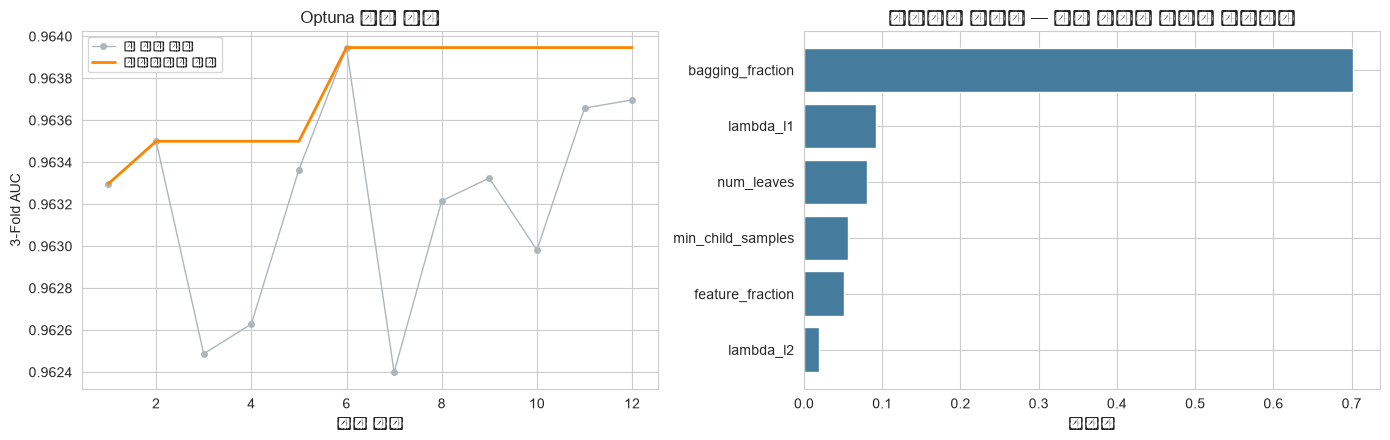

In [12]:
# 시행이 진행되며 점수가 어떻게 개선됐는지 본다.
# 계단이 위로 올라가다 평평해지면 '충분히 탐색했다'는 신호다.
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(range(1, len(vals)+1), vals, 'o-', color='#adb5bd',
             ms=4, lw=1, label='각 시행 점수')
axes[0].plot(range(1, len(vals)+1), best_so_far, lw=2,
             color='#fb8500', label='그때까지의 최고')
axes[0].set_xlabel('시행 횟수'); axes[0].set_ylabel('3-Fold AUC')
axes[0].set_title('Optuna 탐색 과정')
axes[0].legend(fontsize=8)

# 어떤 파라미터가 점수에 크게 영향을 줬는지
try:
    imp = optuna.importance.get_param_importances(study)
    ks, vs = list(imp.keys())[::-1], list(imp.values())[::-1]
    axes[1].barh(ks, vs, color='#457b9d')
    axes[1].set_title('파라미터 중요도 — 어떤 설정이 점수를 좌우했나')
    axes[1].set_xlabel('중요도')
except Exception as e:
    axes[1].text(0.5, 0.5, f'중요도 계산 불가\n{e}', ha='center')

plt.tight_layout(); plt.show()

## 5. 최종 검증 — 튜닝 전후 5-Fold 비교

In [13]:
# 튜닝은 3-Fold로 했으므로, 공정한 비교를 위해 5-Fold로 다시 잰다.
# 학습률도 0.05로 낮춰 정밀도를 높인다 (트리는 더 많이 필요하다).
BEST = dict(objective='binary', metric='auc', verbose=-1, n_jobs=-1,
            random_state=SEED, n_estimators=4000, learning_rate=0.05,
            bagging_freq=1, **study.best_params)
FIT = dict(eval_metric='auc', callbacks=[lgb.early_stopping(100, verbose=False)])

# (1) 튜닝 전 파라미터 + 새 피처셋
DEFAULT = dict(objective='binary', metric='auc', learning_rate=0.05,
               num_leaves=63, min_child_samples=50,
               feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
               n_estimators=4000, verbose=-1, n_jobs=-1, random_state=SEED)

print('[1/2] 튜닝 전 파라미터 + 최종 피처셋')
r_before = run_cv(lambda: lgb.LGBMClassifier(**DEFAULT), X, y, X_test,
                  folds=folds, name='FE only', fit_params=FIT, verbose=False)
print(f"  CV AUC = {r_before['cv_auc']:.6f}")

print('[2/2] 튜닝 후 파라미터 + 최종 피처셋')
r_after = run_cv(lambda: lgb.LGBMClassifier(**BEST), X, y, X_test,
                 folds=folds, name='FE + tuned', fit_params=FIT, verbose=False)
print(f"  CV AUC = {r_after['cv_auc']:.6f}")

[1/2] 튜닝 전 파라미터 + 최종 피처셋


  CV AUC = 0.963951
[2/2] 튜닝 후 파라미터 + 최종 피처셋


  CV AUC = 0.964516


                   단계   CV AUC    누적 개선   단계별 개선
  03. 베이스라인 (원본 12피처) 0.963574 0.000000 0.000000
04. + 피처 엔지니어링 (16피처) 0.963951 0.000378 0.000378
      04. + Optuna 튜닝 0.964516 0.000942 0.000565


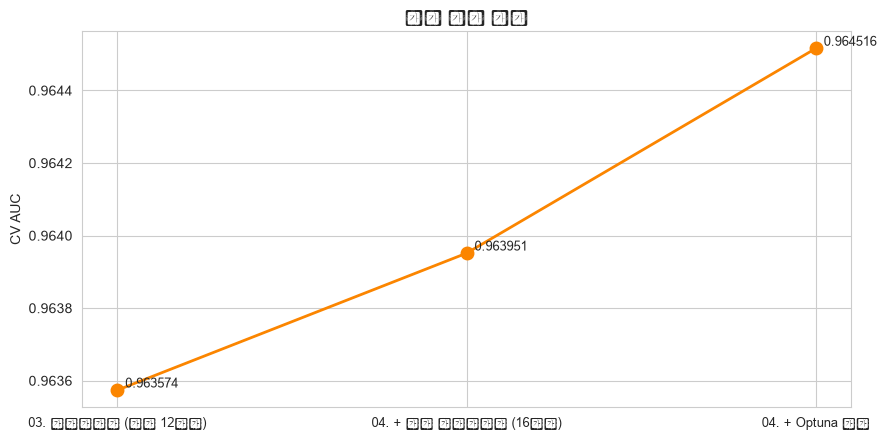

In [14]:
# 03단계 베이스라인 점수를 불러와 전체 개선 과정을 정리한다
import os
base_oof_path = '../preds/oof_lgbm_base.npy'
base_auc = roc_auc_score(y, np.load(base_oof_path)) if os.path.exists(base_oof_path) else np.nan

summary = pd.DataFrame([
    {'단계': '03. 베이스라인 (원본 12피처)', 'CV AUC': base_auc},
    {'단계': '04. + 피처 엔지니어링 (16피처)', 'CV AUC': r_before['cv_auc']},
    {'단계': '04. + Optuna 튜닝', 'CV AUC': r_after['cv_auc']},
])
summary['누적 개선'] = summary['CV AUC'] - summary['CV AUC'].iloc[0]
summary['단계별 개선'] = summary['CV AUC'].diff().fillna(0)
print(summary.round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(summary)), summary['CV AUC'], 'o-', lw=2, ms=9, color='#fb8500')
ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary['단계'], fontsize=9)
ax.set_ylabel('CV AUC')
ax.set_title('개선 과정 추적')
for i, v in enumerate(summary['CV AUC']):
    ax.text(i, v, f'  {v:.6f}', fontsize=9, va='bottom')
plt.tight_layout(); plt.show()

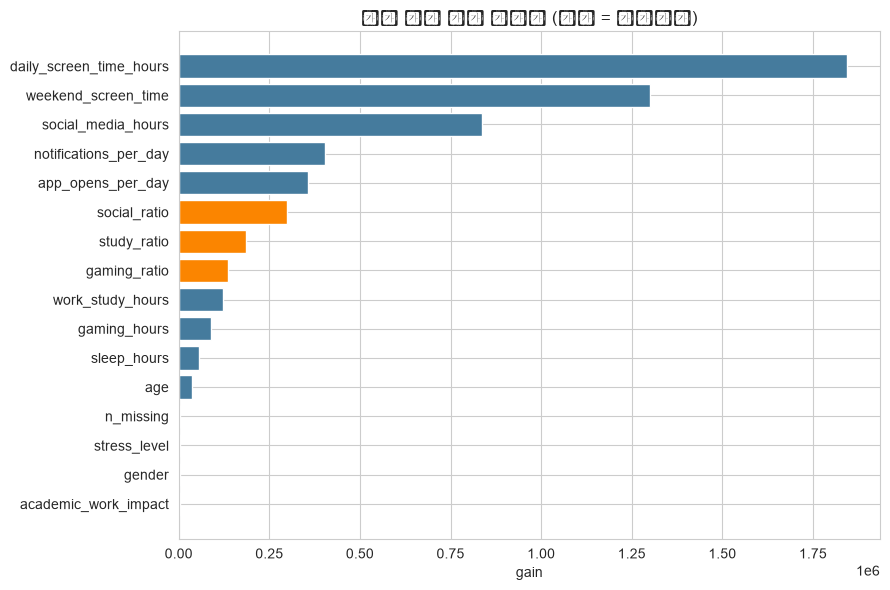

                     변수         gain  gain_비율(%) 종류
daily_screen_time_hours 1.842957e+06       32.46 원본
    weekend_screen_time 1.299236e+06       22.88 원본
     social_media_hours 8.367470e+05       14.74 원본
  notifications_per_day 4.039123e+05        7.11 원본
      app_opens_per_day 3.571975e+05        6.29 원본
           social_ratio 2.984640e+05        5.26 파생
            study_ratio 1.857202e+05        3.27 파생
           gaming_ratio 1.364689e+05        2.40 파생
       work_study_hours 1.208826e+05        2.13 원본
           gaming_hours 8.996110e+04        1.58 원본
            sleep_hours 5.508043e+04        0.97 원본
                    age 3.543914e+04        0.62 원본
              n_missing 4.804107e+03        0.08 파생
           stress_level 4.503034e+03        0.08 원본
                 gender 4.123609e+03        0.07 원본
   academic_work_impact 2.206070e+03        0.04 원본

파생변수가 차지하는 gain 비율: 11.01%


In [15]:
# 최종 모델의 피처 중요도 — 만든 파생변수가 실제로 쓰이는지 확인
fin = lgb.LGBMClassifier(**{**BEST, 'n_estimators': int(np.mean(r_after['best_iters']))})
fin.fit(X, y)

imp = pd.DataFrame({
    '변수': X.columns,
    'gain': fin.booster_.feature_importance('gain'),
})
imp['gain_비율(%)'] = (imp['gain'] / imp['gain'].sum() * 100).round(2)
imp['종류'] = ['파생' if c in SELECTED_EXTRA else '원본' for c in X.columns]
imp = imp.sort_values('gain', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
d = imp.sort_values('gain')
ax.barh(d['변수'], d['gain'],
        color=['#fb8500' if t == '파생' else '#457b9d' for t in d['종류']])
ax.set_title('최종 모델 피처 중요도 (주황 = 파생변수)')
ax.set_xlabel('gain')
plt.tight_layout(); plt.show()

print(imp.to_string(index=False))
print(f"\n파생변수가 차지하는 gain 비율: "
      f"{imp[imp['종류']=='파생']['gain_비율(%)'].sum():.2f}%")

## 6. 결과 저장

In [16]:
os.makedirs('../preds', exist_ok=True)
np.save('../preds/oof_lgbm_tuned.npy', r_after['oof'])
np.save('../preds/test_lgbm_tuned.npy', r_after['test_pred'])

import json
with open('../preds/lgbm_best_params.json', 'w', encoding='utf-8') as f:
    json.dump(study.best_params, f, ensure_ascii=False, indent=2)

sub_v2 = sub.copy()
sub_v2[TARGET] = r_after['test_pred']
sub_v2.to_csv('../submissions/submission_v2_tuned.csv', index=False)

print(f"OOF/테스트 예측 저장 완료")
print(f"제출 파일: submissions/submission_v2_tuned.csv")
print(sub_v2.head(3))

OOF/테스트 예측 저장 완료
제출 파일: submissions/submission_v2_tuned.csv
       id  addicted_label
0  691369        0.999529
1  691370        0.961062
2  691371        0.971276


---
## 📌 04단계 요약

### 배운 것 3가지

**1. 피처는 많을수록 좋은 게 아니다**
파생변수 12개를 전부 넣은 것보다, 효과가 확인된 4개만 넣은 것이 더 높았다.
기여하지 않는 피처는 중립이 아니라 **점수를 깎는다.**

**2. 애블레이션이 답이다**
한 번에 다 넣으면 무엇이 효과가 있었는지 알 수 없다.
그룹을 하나씩 붙이며 순수 효과를 분리해야 판단할 수 있다.

**3. "피처가 튜닝보다 중요하다"는 통념은 항상 맞지 않는다**

이번 실험의 단계별 개선폭은 이랬다.

| 단계 | CV AUC | 단계별 개선 |
|---|---|---|
| 03. 베이스라인 (원본 12피처) | 0.963574 | — |
| 04. + 피처 엔지니어링 (16피처) | 0.963951 | **+0.000378** |
| 04. + Optuna 튜닝 | 0.964516 | **+0.000565** |

**튜닝의 기여가 피처 엔지니어링보다 컸다.** 통념과 반대다. 이유는 이렇게 볼 수 있다.

- **원본 신호가 이미 매우 강하다.** `daily_screen_time` 하나의 상관이 0.611이고
  베이스라인 AUC가 이미 0.9636이다. **짜낼 수 있는 정보가 별로 안 남아 있어서**
  파생변수가 보탤 여지가 작았다. (실제로 파생변수 3개의 gain 비중은 약 11%였다)
- **Optuna가 규제를 크게 바꿨다.** 탐색 결과 `lambda_l1`이 기본값(≈0)에서 약 4.9로,
  `feature_fraction`은 0.8에서 0.53으로 바뀌었다. 유효 변수가 적은 상황에서는
  **불필요한 분기를 억제하는 규제**가 큰 힘을 발휘한다.
- **피처 탐색 공간이 좁았다.** 우리는 파생변수 12개만 만들어봤다. 수십~수백 개를
  만들어 탐색했다면 결과가 달라졌을 수 있다.

> **일반화하지 말고 측정하라.** "무엇이 더 중요한가"는 데이터마다 다르다.
> 통념을 따르되, **자기 데이터에서 직접 재본 숫자**를 최종 근거로 삼아야 한다.
> 이번처럼 통념이 빗나가는 경우가 실제로 있다.

### 다음 단계 (05_ensemble_submit)
- [ ] XGBoost, CatBoost 모델 추가 학습
- [ ] OOF 예측 기반 블렌딩 가중치 탐색
- [ ] 최종 `submission.csv` 생성